# Projet : Prédiction de la Déforestation Mondiale
## Notebook 01 — Exploration, Prétraitement & Feature Engineering

**Dataset** : Global Forest Watch (`global.xlsx`)  
**Objectif** : Préparer les données pour l'entraînement de 4 modèles de prédiction (Régression Linéaire, Random Forest, ANN, CNN)

Ce notebook réalise :
- Le chargement et le nettoyage des données brutes
- Le feature engineering (variables de retard, moyennes mobiles, ratios)
- Le split train/test et la standardisation
- Des visualisations exploratoires
- La sauvegarde des données prétraitées


In [1]:
# Installation des dépendances
!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow openpyxl --quiet

In [2]:
# Import des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Graine pour la reproductibilité
np.random.seed(42)

# Création des dossiers de sortie
os.makedirs('figures', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('data', exist_ok=True)

print('✅ Librairies importées avec succès')

✅ Librairies importées avec succès


In [3]:
# Chargement des feuilles du fichier Excel
EXCEL_PATH = 'global.xlsx'  # Ajustez le chemin si nécessaire

df_tree = pd.read_excel(EXCEL_PATH, sheet_name='Country tree cover loss')
df_drivers = pd.read_excel(EXCEL_PATH, sheet_name='Country drivers')

print('--- Country tree cover loss ---')
print(f'Shape : {df_tree.shape}')
print(df_tree.head(3))
print()
print('--- Country drivers ---')
print(f'Shape : {df_drivers.shape}')
print(df_drivers.head(3))

--- Country tree cover loss ---
Shape : (1880, 30)
       country  threshold   area_ha  extent_2000_ha  extent_2010_ha  \
0  Afghanistan          0  64383655        64383655        64383655   
1  Afghanistan         10  64383655          432070          126231   
2  Afghanistan         15  64383655          302629          106851   

   tc_loss_ha_2001  tc_loss_ha_2002  tc_loss_ha_2003  tc_loss_ha_2004  \
0              103              214              267              225   
1               92              190              254              207   
2               91              186              247              205   

   tc_loss_ha_2005  ...  tc_loss_ha_2016  tc_loss_ha_2017  tc_loss_ha_2018  \
0              268  ...                0                0               32   
1              246  ...                0                0               28   
2              240  ...                0                0               28   

   tc_loss_ha_2019  tc_loss_ha_2020  tc_loss_ha_2021  tc_l

In [4]:
# Filtrage sur threshold == 30 (seuil standard Global Forest Watch)
df_tree_30 = df_tree[df_tree['threshold'] == 30].copy()
df_drivers_30 = df_drivers[df_drivers['threshold'] == 30].copy()

print(f'Après filtrage threshold=30 :')
print(f'  df_tree_30  : {df_tree_30.shape}')
print(f'  df_drivers_30 : {df_drivers_30.shape}')
print(f'  Nombre de pays uniques : {df_tree_30["country"].nunique()}')

Après filtrage threshold=30 :
  df_tree_30  : (235, 30)
  df_drivers_30 : (27231, 5)
  Nombre de pays uniques : 226


In [5]:
# Reshape du format large au format long (une ligne par pays-année)
# Colonnes annuelles : tc_loss_ha_2001 → tc_loss_ha_2023
loss_cols = [c for c in df_tree_30.columns if c.startswith('tc_loss_ha_')]
year_range = [int(c.split('_')[-1]) for c in loss_cols]

# On limite à 2001-2023 pour garder un historique complet
loss_cols_2023 = [c for c in loss_cols if int(c.split('_')[-1]) <= 2023]

df_long = df_tree_30[['country', 'area_ha', 'extent_2000_ha', 'extent_2010_ha'] + loss_cols_2023].melt(
    id_vars=['country', 'area_ha', 'extent_2000_ha', 'extent_2010_ha'],
    value_vars=loss_cols_2023,
    var_name='year_col',
    value_name='tc_loss_ha'
)

# Extraction de l'année depuis le nom de la colonne
df_long['year'] = df_long['year_col'].apply(lambda x: int(x.split('_')[-1]))
df_long = df_long.drop(columns=['year_col'])
df_long = df_long.sort_values(['country', 'year']).reset_index(drop=True)

print(f'Format long : {df_long.shape}')
print(df_long.head(5))

Format long : (5405, 6)
       country   area_ha  extent_2000_ha  extent_2010_ha  tc_loss_ha  year
0  Afghanistan  64383655          205771           71786          88  2001
1  Afghanistan  64383655          205771           71786         179  2002
2  Afghanistan  64383655          205771           71786         244  2003
3  Afghanistan  64383655          205771           71786         201  2004
4  Afghanistan  64383655          205771           71786         236  2005


In [6]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

# Tri par pays et année pour les features temporelles
df_feat = df_long.sort_values(['country', 'year']).copy()

# --- Features de retard (lag features) ---
df_feat['loss_prev_year'] = df_feat.groupby('country')['tc_loss_ha'].shift(1)   # lag-1
df_feat['loss_2yr_ago']   = df_feat.groupby('country')['tc_loss_ha'].shift(2)   # lag-2

# --- Moyenne mobile sur 3 ans ---
df_feat['rolling_mean_3yr'] = (
    df_feat.groupby('country')['tc_loss_ha']
    .transform(lambda x: x.shift(1).rolling(3).mean())
)

# --- Perte cumulée depuis 2001 ---
df_feat['cumulative_loss'] = df_feat.groupby('country')['tc_loss_ha'].cumsum()

# --- Ratio couverture forestière ---
df_feat['forest_cover_ratio'] = df_feat['tc_loss_ha'] / (df_feat['extent_2000_ha'] + 1e-6)

# --- Feature 'year' numérique ---
df_feat['year_num'] = df_feat['year']

# --- Encodage des pays avec LabelEncoder ---
le_country = LabelEncoder()
df_feat['country_encoded'] = le_country.fit_transform(df_feat['country'])

print('Features créées :')
print(df_feat[['country', 'year', 'tc_loss_ha', 'loss_prev_year', 'loss_2yr_ago',
               'rolling_mean_3yr', 'cumulative_loss', 'forest_cover_ratio']].head(8))

Features créées :
       country  year  tc_loss_ha  loss_prev_year  loss_2yr_ago  \
0  Afghanistan  2001          88             NaN           NaN   
1  Afghanistan  2002         179            88.0           NaN   
2  Afghanistan  2003         244           179.0          88.0   
3  Afghanistan  2004         201           244.0         179.0   
4  Afghanistan  2005         236           201.0         244.0   
5  Afghanistan  2006         152           236.0         201.0   
6  Afghanistan  2007         253           152.0         236.0   
7  Afghanistan  2008         108           253.0         152.0   

   rolling_mean_3yr  cumulative_loss  forest_cover_ratio  
0               NaN               88            0.000428  
1               NaN              267            0.000870  
2               NaN              511            0.001186  
3        170.333333              712            0.000977  
4        208.000000              948            0.001147  
5        227.000000             1

In [7]:
# Encodage des drivers dominants (driver principal par pays-année)
df_drivers_pivot = (
    df_drivers_30
    .groupby(['country', 'year', 'driver'])['tc_loss_ha']
    .sum()
    .reset_index()
)

# Driver dominant = celui avec le plus de pertes pour ce pays-année
df_dominant_driver = (
    df_drivers_pivot
    .sort_values('tc_loss_ha', ascending=False)
    .groupby(['country', 'year'])
    .first()
    .reset_index()
    .rename(columns={'driver': 'dominant_driver', 'tc_loss_ha': 'driver_loss_ha'})
)

# Encodage one-hot du driver dominant
df_driver_ohe = pd.get_dummies(df_dominant_driver[['country', 'year', 'dominant_driver']],
                                columns=['dominant_driver'], prefix='driver')

# Fusion avec le dataset principal
df_feat = df_feat.merge(df_driver_ohe, on=['country', 'year'], how='left')

# Colonnes driver générées
driver_cols = [c for c in df_feat.columns if c.startswith('driver_')]
print(f'Drivers encodés ({len(driver_cols)}) :', driver_cols)

Drivers encodés (7) : ['driver_Hard commodities', 'driver_Logging', 'driver_Other natural disturbances', 'driver_Permanent agriculture', 'driver_Settlements & Infrastructure', 'driver_Shifting cultivation', 'driver_Wildfire']


In [8]:
# Gestion des valeurs manquantes
print('Valeurs manquantes avant fillna :')
print(df_feat.isnull().sum()[df_feat.isnull().sum() > 0])

# Remplacement des NaN par 0 (les lags manquent pour les premières années)
df_feat = df_feat.fillna(0)

print('\nValeurs manquantes après fillna :', df_feat.isnull().sum().sum())

Valeurs manquantes avant fillna :
loss_prev_year                         226
loss_2yr_ago                           452
rolling_mean_3yr                       678
driver_Hard commodities                773
driver_Logging                         773
driver_Other natural disturbances      773
driver_Permanent agriculture           773
driver_Settlements & Infrastructure    773
driver_Shifting cultivation            773
driver_Wildfire                        773
dtype: int64

Valeurs manquantes après fillna : 0


In [9]:
# Split train/test temporel
# Train : 2001-2020 | Test : 2021-2023

FEATURE_COLS = (
    ['year_num', 'country_encoded', 'area_ha', 'extent_2000_ha', 'extent_2010_ha',
     'loss_prev_year', 'loss_2yr_ago', 'rolling_mean_3yr',
     'cumulative_loss', 'forest_cover_ratio']
    + driver_cols
)
TARGET_COL = 'tc_loss_ha'

df_train = df_feat[df_feat['year'] <= 2020]
df_test  = df_feat[df_feat['year'] >= 2021]

X_train = df_train[FEATURE_COLS].values
y_train = df_train[TARGET_COL].values
X_test  = df_test[FEATURE_COLS].values
y_test  = df_test[TARGET_COL].values

print(f'Train : {X_train.shape} | Test : {X_test.shape}')
print(f'Features utilisées ({len(FEATURE_COLS)}) : {FEATURE_COLS}')

Train : (4700, 17) | Test : (705, 17)
Features utilisées (17) : ['year_num', 'country_encoded', 'area_ha', 'extent_2000_ha', 'extent_2010_ha', 'loss_prev_year', 'loss_2yr_ago', 'rolling_mean_3yr', 'cumulative_loss', 'forest_cover_ratio', 'driver_Hard commodities', 'driver_Logging', 'driver_Other natural disturbances', 'driver_Permanent agriculture', 'driver_Settlements & Infrastructure', 'driver_Shifting cultivation', 'driver_Wildfire']


In [10]:
# Standardisation avec StandardScaler (fit sur train, transform sur test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Moyenne X_train après scaling : {X_train_scaled.mean():.4f}')
print(f'Écart-type X_train après scaling : {X_train_scaled.std():.4f}')

Moyenne X_train après scaling : 0.0000
Écart-type X_train après scaling : 1.0000


In [11]:
# Sauvegarde des matrices numpy et du scaler
np.save('data/X_train.npy', X_train_scaled)
np.save('data/X_test.npy',  X_test_scaled)
np.save('data/y_train.npy', y_train)
np.save('data/y_test.npy',  y_test)

with open('data/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('data/feature_cols.pkl', 'wb') as f:
    pickle.dump(FEATURE_COLS, f)

print('✅ Données sauvegardées dans data/')

✅ Données sauvegardées dans data/


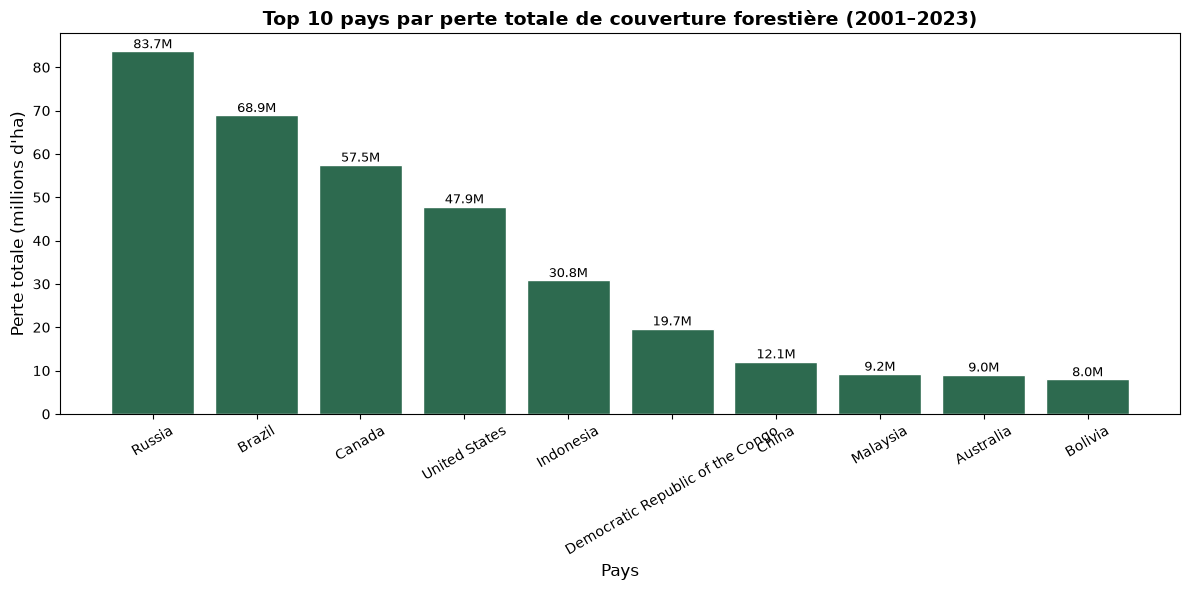

✅ Figure 1 sauvegardée


In [12]:
# Visualisation 1 — Top 10 pays les plus touchés par la déforestation
top10 = (
    df_long.groupby('country')['tc_loss_ha']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(top10['country'], top10['tc_loss_ha'] / 1e6, color='#2d6a4f', edgecolor='white')
ax.set_title('Top 10 pays par perte totale de couverture forestière (2001–2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Pays', fontsize=12)
ax.set_ylabel('Perte totale (millions d\'ha)', fontsize=12)
ax.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, top10['tc_loss_ha']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val/1e6:.1f}M', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('figures/viz1_top10_pays.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 1 sauvegardée')

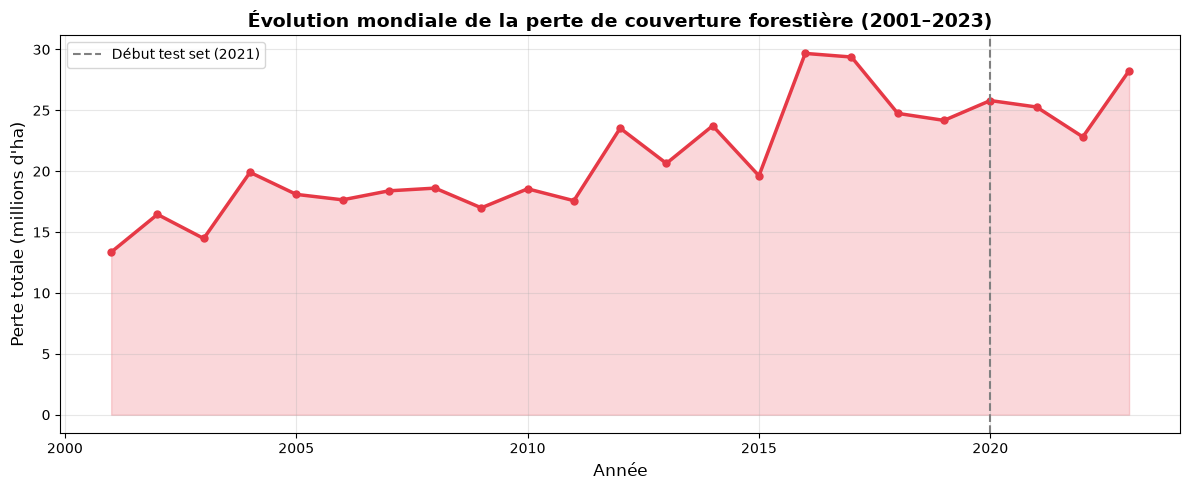

✅ Figure 2 sauvegardée


In [13]:
# Visualisation 2 — Évolution temporelle globale de la déforestation
global_trend = df_long.groupby('year')['tc_loss_ha'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(global_trend['year'], global_trend['tc_loss_ha'] / 1e6,
        marker='o', color='#e63946', linewidth=2.5, markersize=5)
ax.fill_between(global_trend['year'], global_trend['tc_loss_ha'] / 1e6, alpha=0.2, color='#e63946')
ax.set_title('Évolution mondiale de la perte de couverture forestière (2001–2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Année', fontsize=12)
ax.set_ylabel('Perte totale (millions d\'ha)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.axvline(2020, color='gray', linestyle='--', label='Début test set (2021)')
ax.legend()
plt.tight_layout()
plt.savefig('figures/viz2_evolution_globale.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 2 sauvegardée')

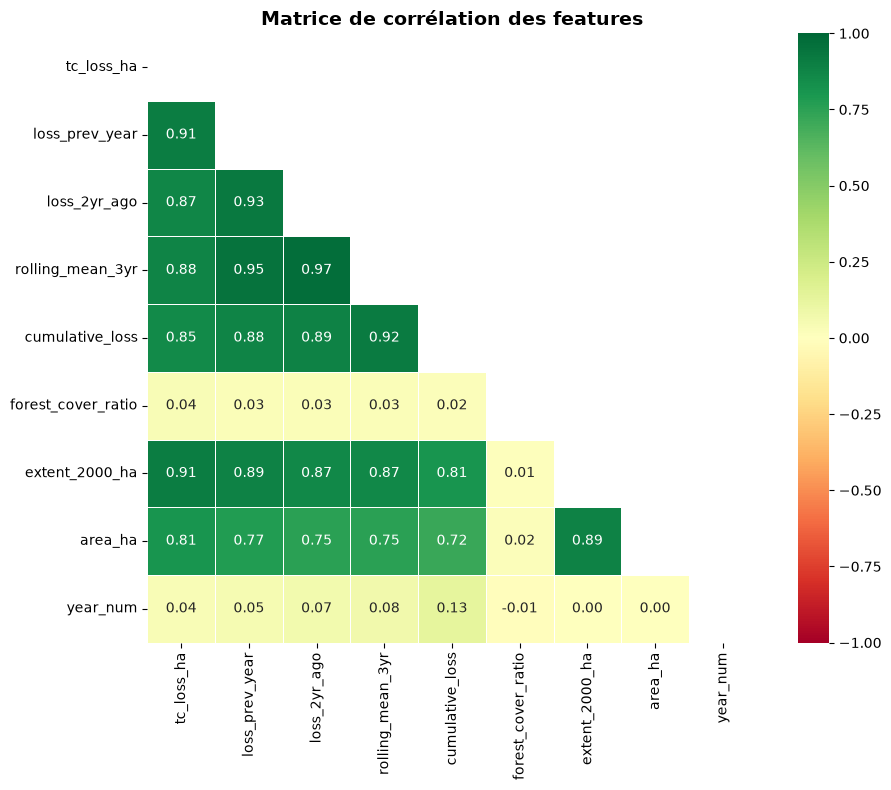

✅ Figure 3 sauvegardée


In [14]:
# Visualisation 3 — Heatmap de corrélation des features numériques
numeric_cols = ['tc_loss_ha', 'loss_prev_year', 'loss_2yr_ago',
                'rolling_mean_3yr', 'cumulative_loss', 'forest_cover_ratio',
                'extent_2000_ha', 'area_ha', 'year_num']

corr_matrix = df_feat[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Matrice de corrélation des features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/viz3_heatmap_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 3 sauvegardée')

In [15]:
# Résumé du preprocessing
print('=' * 55)
print('RÉSUMÉ DU PREPROCESSING')
print('=' * 55)
print(f'Pays uniques           : {df_long["country"].nunique()}')
print(f'Années couvertes       : {df_long["year"].min()} – {df_long["year"].max()}')
print(f'Lignes dataset total   : {df_feat.shape[0]}')
print(f'Nombre de features     : {len(FEATURE_COLS)}')
print(f'Lignes train (≤ 2020)  : {X_train.shape[0]}')
print(f'Lignes test  (≥ 2021)  : {X_test.shape[0]}')
print('='*55)

RÉSUMÉ DU PREPROCESSING
Pays uniques           : 226
Années couvertes       : 2001 – 2023
Lignes dataset total   : 5405
Nombre de features     : 17
Lignes train (≤ 2020)  : 4700
Lignes test  (≥ 2021)  : 705
